In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
debashishsau_aslamerican_sign_language_aplhabet_dataset_path = kagglehub.dataset_download('debashishsau/aslamerican-sign-language-aplhabet-dataset')

print('Data source import complete.')

100%|██████████| 4.20G/4.20G [04:29<00:00, 16.7MB/s]

Extracting files...


Data source import complete.


In [ ]:
import cv2
import numpy as np
import tensorflow as tf

In [ ]:
import os

base_path = debashishsau_aslamerican_sign_language_aplhabet_dataset_path
dataset_root = os.path.join(base_path, "ASL_Alphabet_Dataset")

print(os.listdir(dataset_root))
train_dir = os.path.join(dataset_root, "asl_alphabet_train")
test_dir  = os.path.join(dataset_root, "asl_alphabet_test")

print("Train exists:", os.path.exists(train_dir))
print("Test exists:", os.path.exists(test_dir))

['asl_alphabet_train', 'asl_alphabet_test']
Train exists: True
Test exists: True


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split=0.2
)

# Training generator (shuffle = True is fine here)
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False   # ✅ MUST for correct confusion matrix & graphs
)

Found 178472 images belonging to 29 classes.
Found 44602 images belonging to 29 classes.


In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False   # FREEZE base model

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_initial = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
5578/5578 ━━━━━━━━━━━━━━━━━━━━ 549s 94ms/step - accuracy: 0.7665 - loss: 0.8272 - val_accuracy: 0.8044 - val_loss: 0.7468
Epoch 2/10
5578/5578 ━━━━━━━━━━━━━━━━━━━━ 491s 88ms/step - accuracy: 0.9228 - loss: 0.2622 - val_accuracy: 0.8252 - val_loss: 0.7025
Epoch 3/10
5578/5578 ━━━━━━━━━━━━━━━━━━━━ 520s 93ms/step - accuracy: 0.9495 - loss: 0.1702 - val_accuracy: 0.8277 - val_loss: 0.7159
Epoch 4/10
5578/5578 ━━━━━━━━━━━━━━━━━━━━ 450s 81ms/step - accuracy: 0.9633 - loss: 0.1243 - val_accuracy: 0.8313 - val_loss: 0.7285
Epoch 5/10
5578/5578 ━━━━━━━━━━━━━━━━━━━━ 447s 80ms/step - accuracy: 0.9712 - loss: 0.0981 - val_accuracy: 0.8340 - val_loss: 0.7543
Epoch 6/10
5578/5578 ━━━━━━━━━━━━━━━━━━━━ 451s 81ms/step - accuracy: 0.9757 - loss: 0.0818 - val_accuracy: 0.8369 - val_loss: 0.7724
Epoch 7/10
5578/5578 ━━━━━━━━━━━━━━━━━━━━ 429s 77ms/step - accuracy: 0.9801 - loss: 0.0674 - val_accuracy: 0.8337 - val_loss: 0.8048
Epoch 8/10
5578/5578 ━━━━━━━━━━━━━━━━━━━━ 414s 74ms/step - accuracy: 

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
5578/5578 ━━━━━━━━━━━━━━━━━━━━ 494s 84ms/step - accuracy: 0.9570 - loss: 0.1339 - val_accuracy: 0.8518 - val_loss: 0.7595
Epoch 2/5
  48/5578 ━━━━━━━━━━━━━━━━━━━━ 4:54 53ms/step - accuracy: 0.9799 - loss: 0.0531

KeyboardInterrupt: 

In [ ]:
val_loss, val_acc = model.evaluate(val_generator)
print("✅ Validation Accuracy:", val_acc)

1394/1394 ━━━━━━━━━━━━━━━━━━━━ 148s 106ms/step - accuracy: 0.8738 - loss: 0.8272
✅ Validation Accuracy: 0.8738397359848022


In [ ]:
# Save model
model.save("asl_mobilenetv2_model.h5")

# Save class indices (VERY IMPORTANT)
import json
with open("class_indices.json", "w") as f:
    json.dump(train_generator.class_indices, f)

print("✅ Model & class indices saved locally")


# ---------------- GOOGLE DRIVE ----------------
from google.colab import drive
import shutil

drive.mount('/content/drive')

# Copy model
shutil.copy("asl_mobilenetv2_model.h5", "/content/drive/MyDrive/asl_mobilenetv2_model.h5")

# Copy class indices
shutil.copy("class_indices.json", "/content/drive/MyDrive/class_indices.json")

print("✅ Model & class indices copied to Google Drive")

✅ Model & class indices saved locally
Mounted at /content/drive
✅ Model & class indices copied to Google Drive


In [ ]:
from google.colab import drive
from tensorflow.keras.models import load_model

# Mount Google Drive
drive.mount('/content/drive')

# Path where you saved the model
model_path = "/content/drive/MyDrive/asl_mobilenetv2_model.h5"

# Load the model
asl_model = load_model(model_path)

print("✅ Model loaded successfully from Google Drive")

Mounted at /content/drive


✅ Model loaded successfully from Google Drive


In [ ]:
asl_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,593,375 (9.89 MB)

 Trainable params: 1,861,789 (7.10 MB)

 Non-trainable params: 731,584 (2.79 MB)

 Optimizer params: 2 (12.00 B)

In [ ]:
import json
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model

IMG_SIZE = 224

# Load model
model = load_model("/content/drive/MyDrive/asl_mobilenetv2_model.h5")
print("✅ Model loaded")

# Load class indices
with open("/content/drive/MyDrive/class_indices.json", "r") as f:
    class_indices = json.load(f)

class_names = list(class_indices.keys())
print("✅ Classes loaded:", len(class_names))

✅ Model loaded
✅ Classes loaded: 29


In [ ]:
import matplotlib.pyplot as plt

# Combine both histories
acc = history_initial.history['accuracy'] + history_fine.history['accuracy']
val_acc = history_initial.history['val_accuracy'] + history_fine.history['val_accuracy']

loss = history_initial.history['loss'] + history_fine.history['loss']
val_loss = history_initial.history['val_loss'] + history_fine.history['val_loss']

# Accuracy
plt.figure()
plt.plot(acc)
plt.plot(val_acc)
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.figure()
plt.plot(loss)
plt.plot(val_loss)
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

NameError: name 'history_fine' is not defined

1394/1394 ━━━━━━━━━━━━━━━━━━━━ 141s 98ms/step
✅ Accuracy: 0.8518900497735528
✅ Results saved successfully


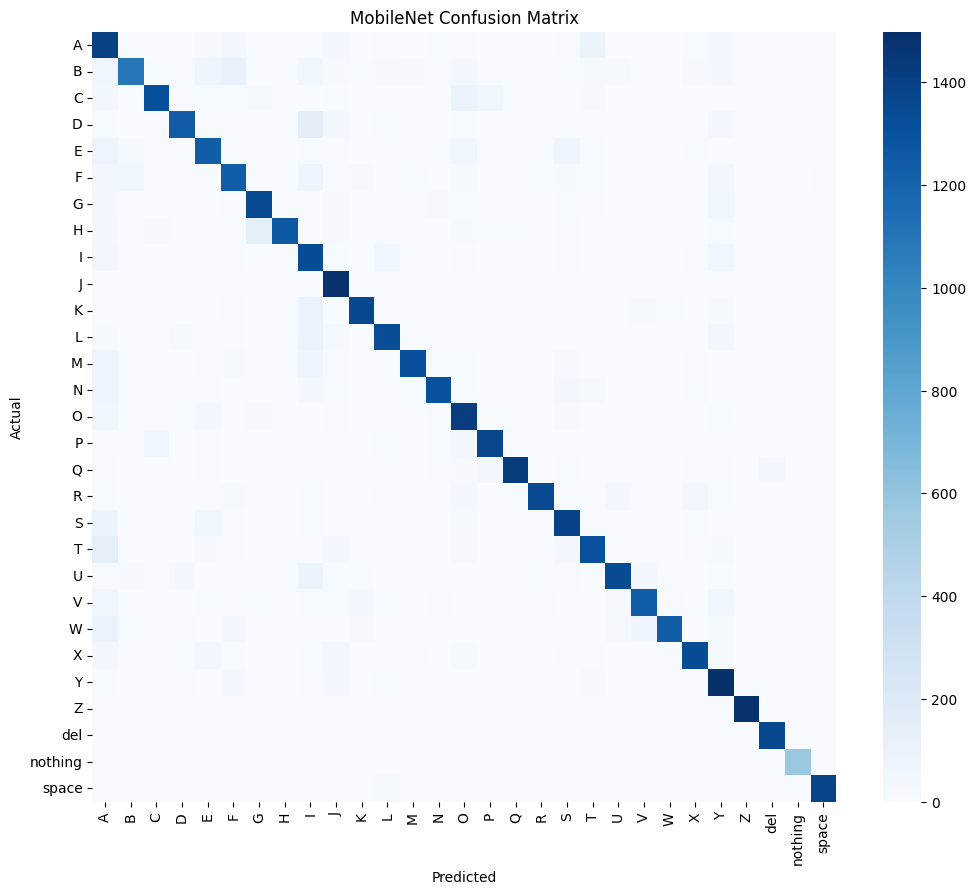

In [ ]:
import numpy as np
import json
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# USE VALIDATION GENERATOR (since test folder not structured)
# --------------------------------------------------

val_generator.reset()

# Predictions
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = val_generator.classes

# Class names (FROM YOUR GENERATOR)
class_names = list(val_generator.class_indices.keys())

# --------------------------------------------------
# METRICS
# --------------------------------------------------

accuracy = accuracy_score(y_true, y_pred)

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

cm = confusion_matrix(y_true, y_pred)

print("✅ Accuracy:", accuracy)

# --------------------------------------------------
# SAVE RESULTS (same format as your other models)
# --------------------------------------------------

results = {
    "model_name": "MobileNetV2_Transfer",
    "accuracy": accuracy,
    "precision": report["macro avg"]["precision"],
    "recall": report["macro avg"]["recall"],
    "f1_score": report["macro avg"]["f1-score"]
}

with open("mobilenet_results.json", "w") as f:
    json.dump(results, f)

np.save("mobilenet_confusion_matrix.npy", cm)
np.save("mobilenet_classes.npy", class_names)

print("✅ Results saved successfully")

# --------------------------------------------------
# CONFUSION MATRIX VISUALIZATION
# --------------------------------------------------

plt.figure(figsize=(12,10))
sns.heatmap(
    cm,
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)

plt.title("MobileNet Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Reset generator
val_generator.reset()

# Predictions
y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = val_generator.classes

# ✅ FIX: get class names
class_names = list(val_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=90)
plt.yticks(tick_marks, class_names)

plt.show()

NameError: name 'val_generator' is not defined

In [ ]:
def predict_asl(input_images):
    # Always treat input as list
    if isinstance(input_images, str):
        input_images = [input_images]

    results = []

    for image_path in input_images:
        img = cv2.imread(image_path)

        if img is None:
            print("❌ Cannot read image:", image_path)
            continue

        # Preprocessing (same as training)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
        img = np.expand_dims(img, axis=0)

        # Prediction
        preds = model.predict(img, verbose=0)
        pred_index = np.argmax(preds)
        letter = class_names[pred_index]

        print(f"🖼 {image_path} → {letter}")

        # Handle special classes
        if letter == "space":
            results.append(" ")
        elif letter == "del":
            if results:
                results.pop()
        elif letter == "nothing":
            continue
        else:
            results.append(letter)

    # Output logic
    if len(input_images) == 1:
        return results[0] if results else None

    return "".join(results)

In [ ]:
result = predict_asl("test1.jpeg")
print("✅ Output:", result)

🖼 test1.jpeg → A
✅ Output: A


In [ ]:
image_list = [
    "test1.jpeg",
    "test2.jpeg",
    "test2.jpeg",
    "test3.jpeg",
    "test4.jpeg"
]

result = predict_asl(image_list)
print("✅ Predicted Word:", result)

🖼 test1.jpeg → A
🖼 test2.jpeg → P
🖼 test2.jpeg → P
🖼 test3.jpeg → L
🖼 test4.jpeg → E
✅ Predicted Word: APPLE
